# NLP Analysis on Tweets for Emoji Prediction, Named Entity Recognition & Semantic Relations

In this project, we analyze *5,000 tweets from the validation split* of the `tweet_eval` dataset (**emoji configuration**), with the goal of exploring the relationship between textual content and the 20 emoji labels associated with classes (0–19).

Using NLP tools (spaCy, NLTK and WordNet) for linguistic analysis, we focused on the `distribution of hashtags and mentions in relation to labels`, and implemented a `classification approach using pretrained embeddings and a simple neural network` (MLPClassifier).

The project also includes explanatory visualizations and a final focus on the most frequent words, enriched with **semantic relations derived from WordNet**.

### Let’s start by importing the necessary libraries, including linguistic resources

In addition to the NLP libraries mentioned above, we import tools for data manipulation (`pandas`, `re`), visualization (`matplotlib`, where we **set a consistent font for all plots** using `plt.rcParams`), and classification (`scikit-learn`, `sentence-transformers`).

We also initialize the base `spaCy` model (`en_core_web_sm`) for tokenization and Named Entity Recognition, and load English stopwords from `nltk` to filter out non-informative words.

In [1]:
# Run only if needed (first time setup)
# !python -m spacy download en_core_web_sm
# import nltk
# nltk.download("stopwords")
# nltk.download("wordnet")

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "DejaVu Sans"
import spacy  # For tokenization, lemmatization and Named Entity Recognition
from nltk.corpus import stopwords 
from nltk.corpus import wordnet as wn #only for the most frequent words at the end
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sentence_transformers import SentenceTransformer
from collections import defaultdict
import html #to solve the problem with the  entity &amp; and others
from sklearn.neural_network import MLPClassifier


nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words("english"))

### Dataset loading and preparation

After *loading the dataset* using the `datasets` library and selecting the 5,000 tweets from the validation split of `tweet_eval` (**emoji configuration**), we **convert it into a Pandas DataFrame** for easier handling, remove any **HTML entities** from the tweets (such as `&amp;`), and **split the dataset into two halves**: one to simulate training and the other for testing.

We also chose to implement a **mapping between numerical labels and emojis using a dictionary**, which we use before plotting hashtag histograms to display a **legend**. This helps match labels with emojis, especially in the initial phase, since `emoji representations were not always clearly displayed in the plots`.

In [3]:

dataset = load_dataset("cardiffnlp/tweet_eval", "emoji", split="validation")
df = dataset.to_pandas()
df["text"] = df["text"].apply(html.unescape)

# We use the functions sample and drop as taken from StackOverflow
train_df = df.sample(frac=0.5, random_state=42)
test_df = df.drop(train_df.index)


label_to_emoji = {
    0: "❤", 1: "😍", 2: "😂", 3: "💕", 4: "🔥",
    5: "😊", 6: "😎", 7: "✨", 8: "💙", 9: "😘",
    10: "📷", 11: "🇺🇸", 12: "☀", 13: "💜", 14: "😉",
    15: "💯", 16: "😁", 17: "🎄", 18: "📸", 19: "😜"
}

### Linguistic preprocessing and initial textual features

In this first phase, we **normalize and clean the text** by *removing stopwords and symbols*, *filtering short words*, *lemmatizing tokens*, and *storing the results in a new column*. This processed text is later used to compute the ten most frequent words for the final linguistic analysis with WordNet.

Next, we also **extract hashtags (#) using regular expressions**, storing them in a separate column. Both transformations are applied only to the training set for exploratory analysis.

In [4]:
# Function to clean and lemmatize a tweet
def clean_and_lemmatize_tweet(tweet):
    doc = nlp(tweet)
    return [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha and token.text.lower() not in stop_words and len(token.lemma_) > 2
    ]

# Apply preprocessing to both training and test sets
train_df["lemmas"] = [clean_and_lemmatize_tweet(tweet) for tweet in train_df["text"]]
test_df["lemmas"] = [clean_and_lemmatize_tweet(tweet) for tweet in test_df["text"]]


# Function to extract hashtags using regular expressions
def extract_hashtags(tweet):
    return re.findall(r"#\w+", tweet)

# Store hashtags in a separate column (training set only)
train_df["hashtags"] = [extract_hashtags(tweet) for tweet in train_df["text"]]

## Hashtag frequency and distribution by label

We build a **nested dictionary using `defaultdict`** and an anonymous `lambda` function to count the frequency of each individual hashtag for every numerical label. We then **sum these frequencies regardless of class** and visualize their *distribution across all 20 possible labels* (0–19) with a separate **bar chart** for each hashtag.

For the visualization, in addition to axis labels, frequencies, and titles, we use a few plotting settings to make the charts easier to read.

Legend: label → emoji
 0 → ❤
 1 → 😍
 2 → 😂
 3 → 💕
 4 → 🔥
 5 → 😊
 6 → 😎
 7 → ✨
 8 → 💙
 9 → 😘
10 → 📷
11 → 🇺🇸
12 → ☀
13 → 💜
14 → 😉
15 → 💯
16 → 😁
17 → 🎄
18 → 📸
19 → 😜


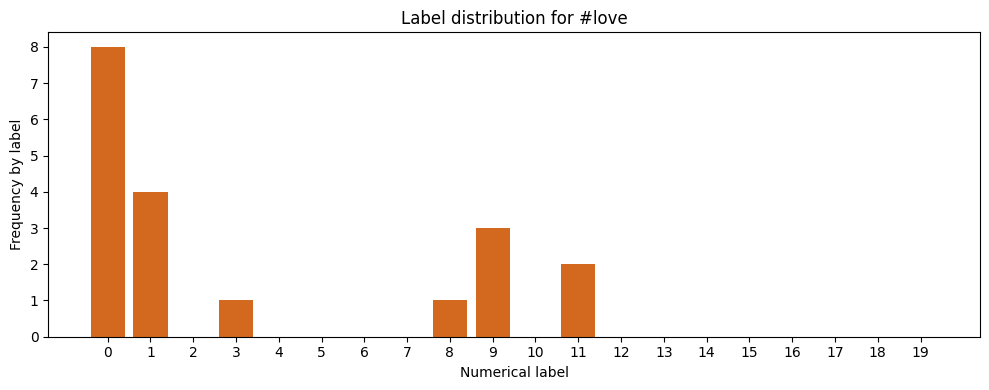

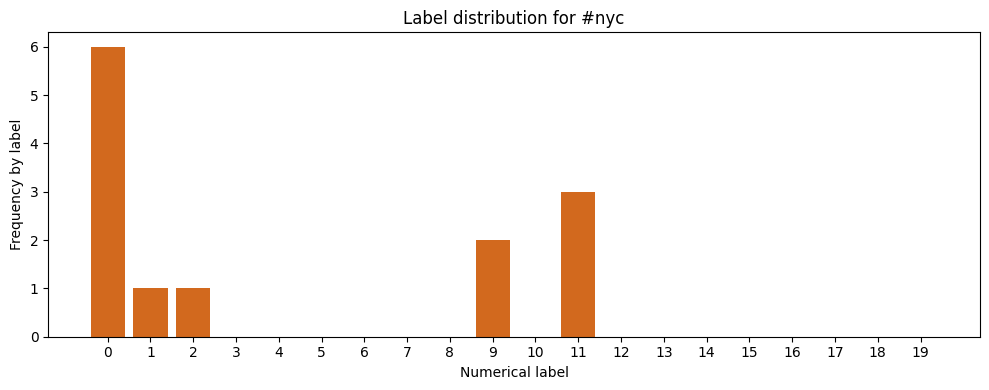

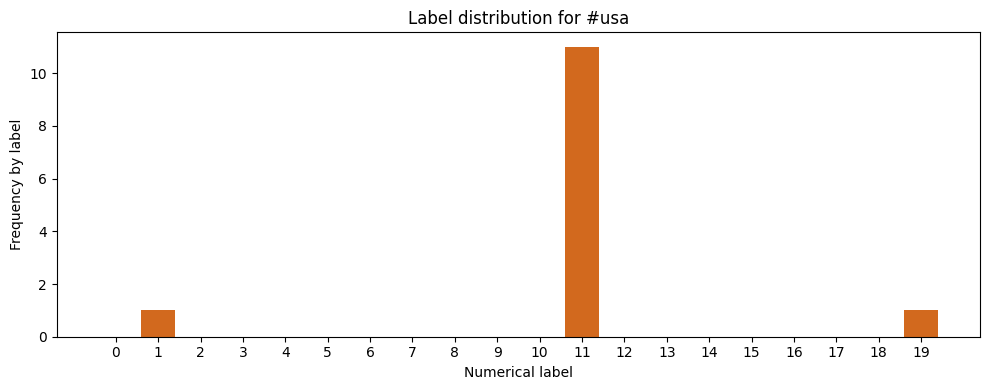

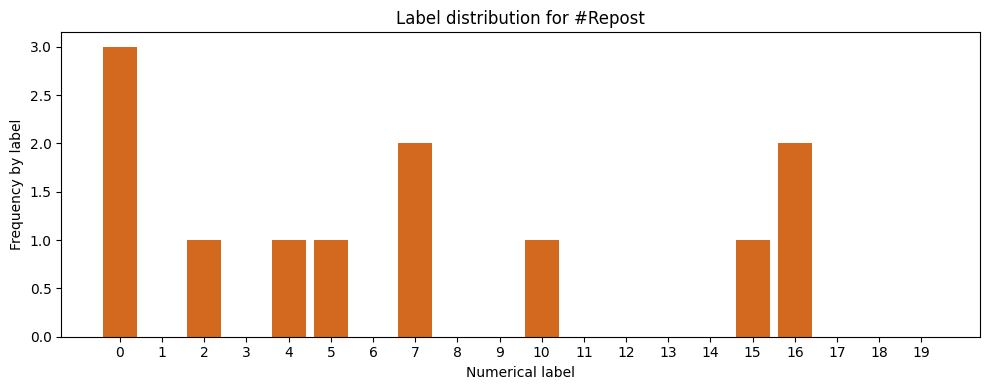

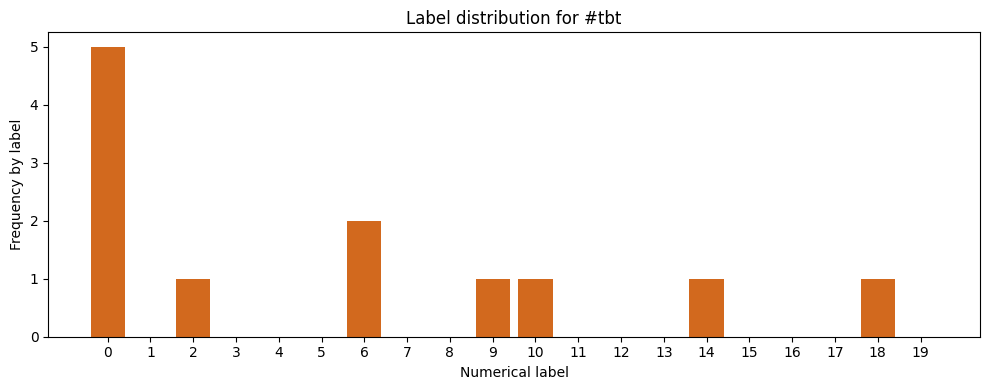

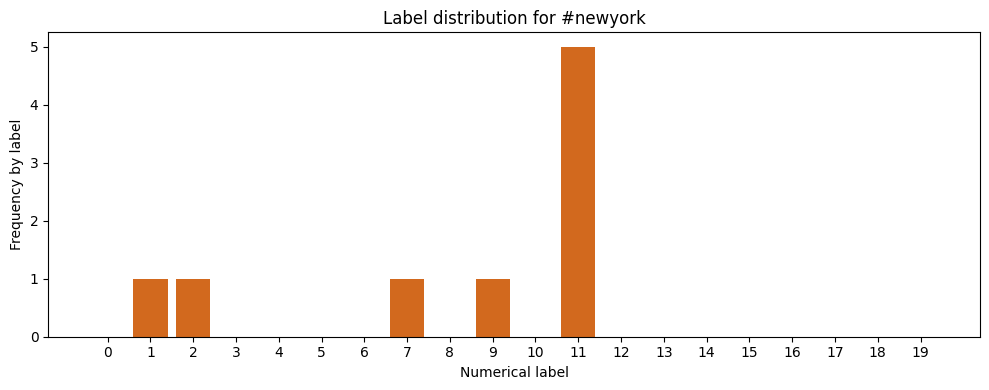

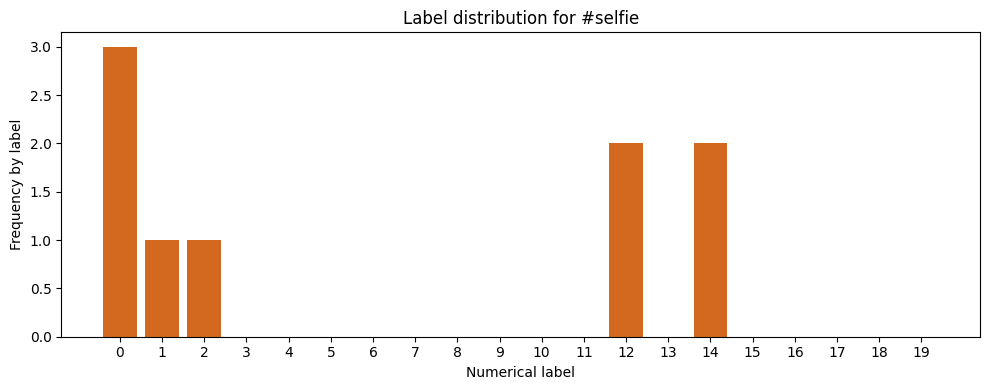

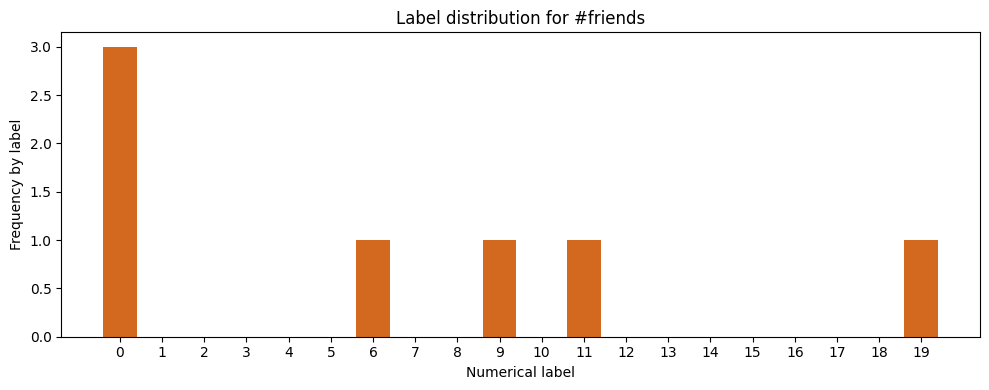

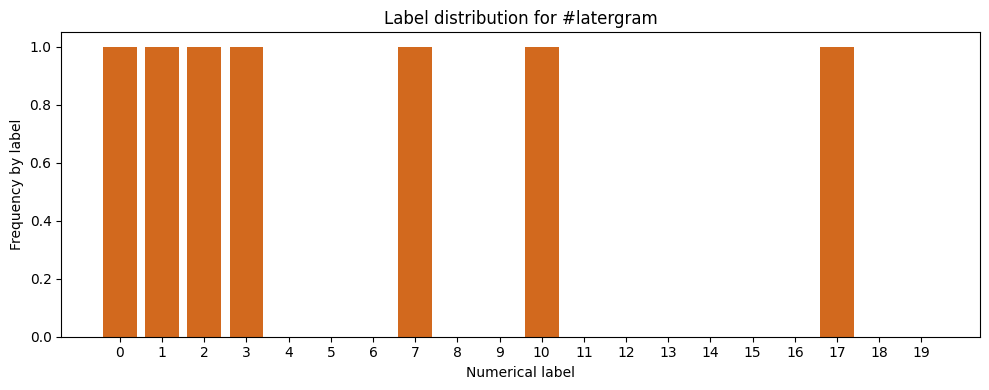

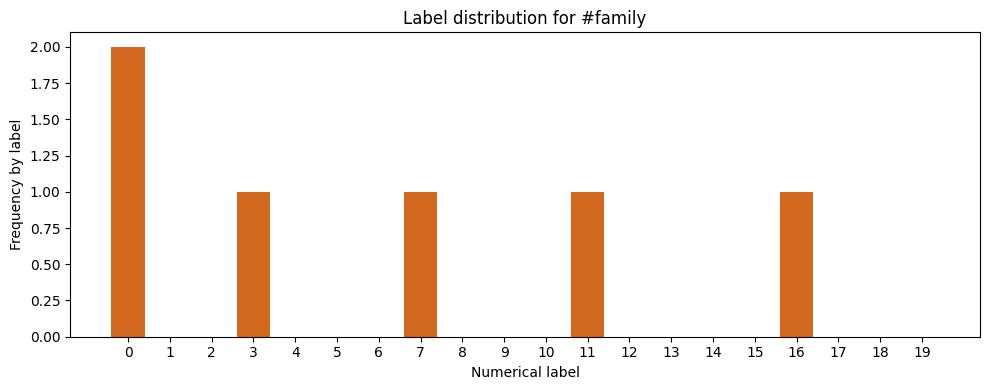

In [5]:
# We use a dictionary of dictionaries to store each hashtag
# and its frequency in relation to each label
hashtag_dict = defaultdict(lambda: defaultdict(int))

for i, tweet_row in train_df.iterrows():
    hashtag_list = tweet_row["hashtags"]
    label = tweet_row["label"]

    for hashtag in hashtag_list:
        hashtag_dict[hashtag][label] += 1

# We compute the total frequency of each hashtag
# in order to identify the 10 most frequent ones
total_hashtag_frequencies = {
    hashtag: sum(hashtag_dict[hashtag].values())
    for hashtag in hashtag_dict
}

top_10_hashtags = sorted(
    total_hashtag_frequencies,
    key=total_hashtag_frequencies.get,
    reverse=True
)[:10]

# We print a legend to help match numerical labels with emojis
print("Legend: label → emoji")
for i in range(20):
    print(f"{i:>2} → {label_to_emoji[i]}")

# We create one bar chart for each hashtag,
# showing numerical labels and their frequencies
for hashtag in top_10_hashtags:
    # List of frequencies for each label from 0 to 19
    frequencies_per_label = [
        hashtag_dict[hashtag].get(i, 0)
        for i in range(20)
    ]

    label_numbers = [str(i) for i in range(20)]

    # Bar chart for each hashtag
    plt.figure(figsize=(10, 4))
    plt.bar(range(20), frequencies_per_label, color="#D2691E")  # Chocolate
    plt.xlabel("Numerical label")
    plt.ylabel("Frequency by label")
    plt.title(f"Label distribution for {hashtag}")
    plt.xticks(range(20), label_numbers)
    plt.tight_layout()
    plt.show()

## Named entity frequency and distribution by label

As we did for hashtags, we now build a **nested dictionary for named entities as well**, extracting them only when they appear **after a mention marked with @ (at sign + space)**.

Here too, we analyze their *frequency in relation to the associated labels*, compute their *overall frequency*, and display the *ten most frequently mentioned entities*.

In addition to the *bar chart* visualization, we also **print the results beforehand** to make it easier to match each entity with the corresponding emojis.

Entity: New York
  → Label 9 😘: 2 times
  → Label 14 😉: 1 times
  → Label 0 ❤: 5 times
  → Label 11 🇺🇸: 1 times
  → Label 6 😎: 2 times
  → Label 10 📷: 1 times
  → Label 7 ✨: 1 times
  → Label 3 💕: 1 times
  → Label 5 😊: 1 times
  → Label 8 💙: 1 times
----------------------------------------
Entity: Los Angeles
  → Label 16 😁: 1 times
  → Label 7 ✨: 4 times
  → Label 17 🎄: 2 times
  → Label 2 😂: 2 times
  → Label 8 💙: 1 times
----------------------------------------
Entity: Disney
  → Label 7 ✨: 3 times
  → Label 13 💜: 1 times
  → Label 3 💕: 1 times
----------------------------------------
Entity: Houston
  → Label 2 😂: 1 times
  → Label 1 😍: 1 times
  → Label 10 📷: 1 times
  → Label 7 ✨: 1 times
----------------------------------------
Entity: Disney's
  → Label 13 💜: 3 times
  → Label 12 ☀: 1 times
----------------------------------------
Entity: Athens
  → Label 0 ❤: 1 times
  → Label 3 💕: 1 times
  → Label 5 😊: 1 times
----------------------------------------
Entity: Las Vegas
  → L

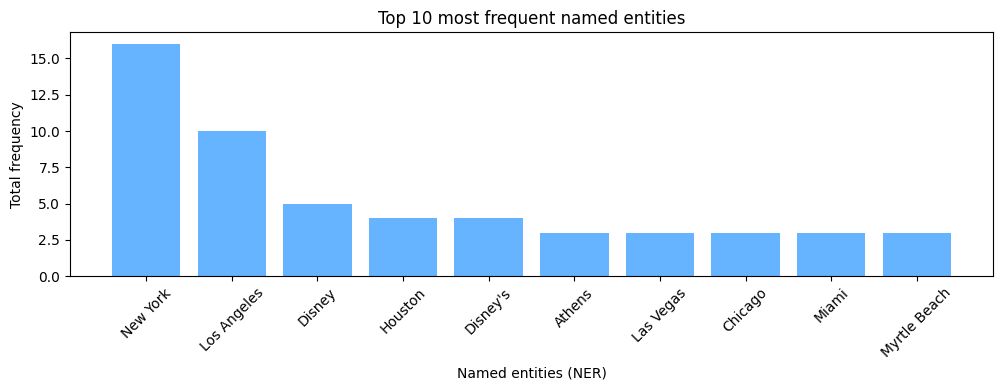

In [6]:
# We identify entities in tweets when they are preceded
# by "@ " (at sign + space), then store them in a new column
def find_entities_after_mention(tweet):
    doc = nlp(tweet)
    mentioned_entities = []
    for ent in doc.ents:
        start = ent.start_char
        if tweet[start - 2:start] == "@ ":
            mentioned_entities.append(ent.text)
    return mentioned_entities

train_df["mentioned_entities"] = [
    find_entities_after_mention(tweet) for tweet in train_df["text"]
]

# We build another nested dictionary to associate each entity
# with its label and frequency count
entity_dict = defaultdict(lambda: defaultdict(int))

for i, tweet_row in train_df.iterrows():
    entity_list = tweet_row["mentioned_entities"]
    label = tweet_row["label"]

    for entity in entity_list:
        entity_dict[entity][label] += 1

# We compute the total frequency of each entity
# by summing all label counts
total_entity_frequencies = {
    entity: sum(entity_dict[entity].values()) for entity in entity_dict
}

# We select the 10 most frequently mentioned entities
top_10_entities = sorted(
    total_entity_frequencies,
    key=total_entity_frequencies.get,
    reverse=True
)[:10]

# We print the 10 most frequent named entities
# and their distribution by label
for entity in top_10_entities:
    print(f"Entity: {entity}")
    for label, count in entity_dict[entity].items():
        print(f"  → Label {label} {label_to_emoji[label]}: {count} times")
    print("-" * 40)

# We also create a bar chart to visualize them
top_entities = top_10_entities  # Alias to improve readability in plots
frequencies_per_entity = [total_entity_frequencies[ent] for ent in top_entities]

plt.figure(figsize=(10, 4))
plt.bar(top_entities, frequencies_per_entity, color="#66B3FF")
plt.xlabel("Named entities (NER)")
plt.ylabel("Total frequency")
plt.title("Top 10 most frequent named entities")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Tweet classification with embeddings and MLPClassifier

In this section, we prepare the training and test data by first converting the `Pandas.Series` objects into lists of strings, in order to compute sentence embeddings using the `paraphrase-mpnet-base-v2` model. We then train an `MLPClassifier` to predict the labels. Finally, we evaluate the model’s performance using a classification `report` and a `Confusion Matrix`.

In [7]:
# Prepare data for sentence embeddings using a pretrained model

X_train = train_df["text"].to_list()
y_train = train_df["label"].to_list()

X_test = test_df["text"].to_list()
y_test = test_df["label"].to_list()

model_embedding = SentenceTransformer("paraphrase-mpnet-base-v2")

embedding_X_train = model_embedding.encode(X_train)
embedding_X_test = model_embedding.encode(X_test)

# We use an MLPClassifier for the classification task

clf = MLPClassifier(hidden_layer_sizes=(256,), random_state=42, max_iter=300)
clf.fit(embedding_X_train, y_train)
y_pred = clf.predict(embedding_X_test)

# Evaluate the model, showing metrics with three decimal digits for better precision

print("Final classification report:")
print(classification_report(y_test, y_pred, digits=3))

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Final classification report:
              precision    recall  f1-score   support

           0      0.300     0.415     0.348       518
           1      0.178     0.184     0.181       255
           2      0.355     0.389     0.371       270
           3      0.074     0.085     0.079       142
           4      0.260     0.260     0.260       123
           5      0.095     0.098     0.096       112
           6      0.098     0.074     0.084       108
           7      0.096     0.078     0.086       103
           8      0.133     0.090     0.107        89
           9      0.040     0.024     0.030        83
          10      0.218     0.202     0.210        84
          11      0.231     0.234     0.233        64
          12      0.226     0.206     0.215        68
          13      0.071     0.048     0.058        83
          14      0.041     0.030     0.035        66
          15      0.123     0.100     0.110        70
          16      0.116     0.072     0.089        6

## Final considerations on classification

Despite the use of a strong contextual embedding model (`paraphrase-mpnet-base-v2`) and an MLP classifier, the classification results are not particularly high (below 50%). Even when testing a more powerful model such as `cardiffnlp/twitter-roberta-base-emoji`, specifically trained for similar tweet-based tasks, the improvements were limited.

This confirms the **complexity and noise typical of tweets**, which often contain slang, abbreviations, symbols, emojis, implicit references, cultural cues, and very short text length. These implicit features make the automatic association between text and label more difficult.

The model was still able to capture some general relationships between text and labels, but the heterogeneity of the data (including dataset imbalance) would likely require more advanced fine-tuning approaches.

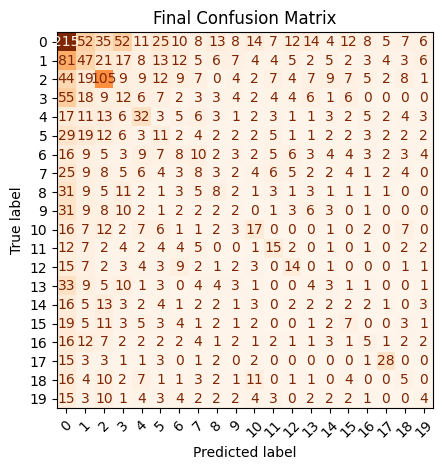

In [8]:
# Final confusion matrix to understand where classes were predicted correctly or incorrectly
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=[str(i) for i in range(20)])
disp.plot(xticks_rotation=45, cmap="Oranges", colorbar=False)
plt.title("Final Confusion Matrix")
plt.tight_layout()
plt.show()

The `Confusion Matrix` shows a **partially visible diagonal** (correct predictions), but also a **significant dispersion**, indicating the difficulty of classifying tweets, a short, noisy, and highly variable text genre. This reflects the semantic and stylistic complexity typical of social media content.

## Semantic analysis with WordNet on the most frequent words

As a final step, we revisited the `lemmas` column created during the initial preprocessing phase: each row contains a list of lemmas for each tweet.

We built a frequency dictionary using `defaultdict` and selected the 10 most frequent words, excluding those that are too short. On these words, we performed a lexical analysis with WordNet, exploring for each one its main synset, definition, possible usage examples, and some semantic relations (hypernyms, hyponyms, antonyms).

In [9]:
# WordNet analysis on the most frequent words

# Create a dictionary to count all lemmatized words
word_counts = defaultdict(int)

for lemma_list in train_df["lemmas"]:
    for lemma in lemma_list:
        word_counts[lemma] += 1

# Select the 10 most frequent words with at least 3 characters (descending order)
frequent_words = sorted(
    [w for w in word_counts if len(w) > 2],
    key=word_counts.get,
    reverse=True
)[:10]

# Print WordNet information for each word, including basic semantic relations
print("\n*** WordNet analysis of the 10 most frequent words ***:\n")

for word in frequent_words:
    frequency = word_counts[word]
    synsets = wn.synsets(word)

    if synsets:
        main_synset = synsets[0]

        print("\n" + "*" * 40)
        print(f"🔸 Word: {word}, Frequency: {frequency}")
        print(f"   → Synset name: {main_synset.name()}")
        print(f"   → Definition: {main_synset.definition()}")
        print(f"   → Example: {main_synset.examples()}")
        print("\n" + "*" * 40)

        hypernyms = main_synset.hypernyms()
        hyponyms = main_synset.hyponyms()
        antonyms = main_synset.lemmas()[0].antonyms()

        if hypernyms:
            print(f"   → Hypernym: {hypernyms[0].name().split('.')[0]}")
        if hyponyms:
            print(f"   → Hyponym: {hyponyms[0].name().split('.')[0]}")
        if antonyms:
            print(f"   → Antonym: {antonyms[0].name()}")

        print("-" * 40)
    else:
        print(f"🔸 Word: {word} → No synset found\n" + "*" * 40)


*** WordNet analysis of the 10 most frequent words ***:


****************************************
🔸 Word: love, Frequency: 227
   → Synset name: love.n.01
   → Definition: a strong positive emotion of regard and affection
   → Example: ['his love for his work', 'children need a lot of love']

****************************************
   → Hypernym: emotion
   → Hyponym: devotion
   → Antonym: hate
----------------------------------------

****************************************
🔸 Word: new, Frequency: 146
   → Synset name: new.a.01
   → Definition: not of long duration; having just (or relatively recently) come into being or been made or acquired or discovered
   → Example: ['a new law', 'new cars', 'a new comet', 'a new friend', 'a new year', 'the New World']

****************************************
   → Antonym: old
----------------------------------------

****************************************
🔸 Word: good, Frequency: 135
   → Synset name: good.n.01
   → Definition: benefit
  

### Final considerations on semantic analysis

The analysis of the 10 most frequent words highlights a vocabulary strongly influenced by emotions and everyday language typical of tweets, including terms such as `love`, `happy`, `good`, and `thank`.

The recurrence of `day` and `night` suggests a temporal dimension in the narratives, while the presence of `new` and `get` may indicate a tendency toward novelty and desire, which is common in social media contexts.

Words such as `beach` suggest that many tweets may refer to summer experiences, photos, or memories (as previously observed with hashtags like `#Repost` and `#tbt` – Throwback Thursday, where users share old photos or memories every Thursday).

In the case of the word *york* (where one might expect *new york*), the lemmatizer splits the expression and treats *york* as an independent token. This shows that linguistic preprocessing can introduce semantic ambiguities related to context. A possible extension could involve using tokenizers specifically designed for social media (e.g. `TweetTokenizer`).